# Michigan Traders — Module 1
# NumPy for Quants

**Series:** MAT Education · Foundations
**Level:** Intermediate (you know Python; here we build the numerical muscle quant work runs on)
**Format:** Fully worked, **runnable** walkthrough — execute every cell, read the output, then tweak it.

---

Almost every quantitative idea you'll meet this year — returns, volatility, Sharpe ratios, covariance matrices, Monte-Carlo simulation, the math inside an ML model — is, under the hood, **array arithmetic**. NumPy is the library that makes that arithmetic fast, concise, and correct.

This notebook teaches NumPy *through finance*: every concept is demonstrated on prices, returns, and portfolios — the exact objects you'll manipulate on QuantConnect and in datathons.

> **Why this comes first.** QuantConnect's research environment hands you data as NumPy/Pandas objects. Pandas (next notebook) is built *on top of* NumPy. If arrays, broadcasting, and `axis` are second nature, everything downstream is easy. If they're not, you'll fight the tools instead of the markets.

## How to use this notebook

Unlike the QuantConnect notebooks later in the series, **this one runs in a normal Jupyter kernel** — no platform needed. You only need NumPy:

```bash
pip install numpy        # (matplotlib too, for the one optional plot near the end)
```

Run the cells top to bottom. We seed the random number generator so your numbers match the comments. Where output is shown, it was produced by actually running the cell.

## 1. Why NumPy? Arrays vs. Python lists

A Python list can hold anything, but math on it is slow and verbose — you loop element by element. A **NumPy array** (`ndarray`) holds one dtype in a contiguous block of memory, so operations run as compiled, vectorized C loops.

Two things to internalize:
1. **Vectorization** — write `a + b`, not a `for` loop. It's shorter *and* often 10–100× faster.
2. **Element-wise by default** — arithmetic between arrays acts element-by-element.

In [1]:
import numpy as np
import time

# Same data as a list and as an array.
n = 1_000_000
py_list = list(range(n))
np_arr = np.arange(n)

# Square every element — the list way (explicit loop):
t0 = time.perf_counter()
list_result = [x * x for x in py_list]
t_list = time.perf_counter() - t0

# Square every element — the NumPy way (vectorized):
t0 = time.perf_counter()
arr_result = np_arr * np_arr
t_arr = time.perf_counter() - t0

print(f"list comprehension: {t_list*1000:7.1f} ms")
print(f"numpy vectorized:   {t_arr*1000:7.1f} ms")
print(f"speedup:            {t_list/t_arr:7.1f}x  (varies by machine)")

list comprehension:    29.9 ms
numpy vectorized:       3.3 ms
speedup:                9.1x  (varies by machine)


The exact speedup varies, but the lesson is permanent: **in quant code, reach for a vectorized array operation before you write a Python loop.** A backtest that loops in Python over millions of bars can be minutes slower than the same logic vectorized.

## 2. Creating arrays

You'll create arrays from existing data, from ranges, or filled with constants/random values.

In [2]:
# From a Python list:
prices = np.array([100.0, 101.5, 99.8, 102.3, 103.1])
print("from list:", prices)

# Ranges:
print("arange:   ", np.arange(0, 10, 2))        # start, stop (exclusive), step
print("linspace: ", np.linspace(0, 1, 5))       # 5 evenly spaced points, endpoints included

# Filled arrays (great for pre-allocating):
print("zeros:    ", np.zeros(4))
print("ones:     ", np.ones(3))
print("full:     ", np.full(3, 0.05))           # e.g. an equal-weight vector

# 2D (a matrix) — think: rows = days, columns = assets:
mat = np.array([[1.0, 2.0, 3.0],
                [4.0, 5.0, 6.0]])
print("2D matrix:\n", mat)

# Random data with a SEEDED generator (reproducible — always seed in research):
rng = np.random.default_rng(42)
print("random normals:", rng.normal(0, 1, size=4))

from list: [100.  101.5  99.8 102.3 103.1]
arange:    [0 2 4 6 8]
linspace:  [0.   0.25 0.5  0.75 1.  ]
zeros:     [0. 0. 0. 0.]
ones:      [1. 1. 1.]
full:      [0.05 0.05 0.05]
2D matrix:
 [[1. 2. 3.]
 [4. 5. 6.]]
random normals: [ 0.30471708 -1.03998411  0.7504512   0.94056472]


## 3. Shape, dtype, and reshaping

Every array has a **shape** (its dimensions) and a **dtype** (its element type). Bugs in quant code are very often shape bugs — get in the habit of printing `.shape`.

In [3]:
returns_matrix = rng.normal(0, 0.01, size=(252, 4))   # 252 trading days x 4 assets

print("shape:", returns_matrix.shape)   # (252, 4)
print("ndim: ", returns_matrix.ndim)    # 2
print("size: ", returns_matrix.size)    # 1008 total elements
print("dtype:", returns_matrix.dtype)   # float64

# Reshape (no data copied — just a new view of the same buffer):
flat = np.arange(12)
print("reshaped 3x4:\n", flat.reshape(3, 4))

# Cast dtype when needed:
print("as int:", np.array([1.9, 2.1, 3.7]).astype(int))   # truncates toward zero

shape: (252, 4)
ndim:  2
size:  1008
dtype: float64
reshaped 3x4:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
as int: [1 2 3]


## 4. Indexing & slicing — and the views-vs-copies trap

Indexing NumPy arrays mirrors lists for 1D, and extends naturally to 2D with `arr[rows, cols]`.

**The trap that bites everyone once:** a basic slice returns a *view*, not a copy. Writing into the slice mutates the original array. Use `.copy()` when you need independence.

In [4]:
prices = np.array([100., 101., 102., 103., 104., 105.])

print("first 3:     ", prices[:3])
print("last 2:      ", prices[-2:])
print("every other: ", prices[::2])

# 2D: rows = days, cols = assets
data = np.arange(12).reshape(4, 3)   # 4 days, 3 assets
print("\nmatrix:\n", data)
print("day 0, asset 1:", data[0, 1])
print("all days, asset 2:", data[:, 2])      # a whole column
print("day 1, all assets:", data[1, :])      # a whole row

# VIEW vs COPY
view = prices[:3]
view[0] = -999            # this also changes `prices`!
print("\nafter writing into a slice:", prices)

prices = np.array([100., 101., 102., 103., 104., 105.])
safe = prices[:3].copy()
safe[0] = -999            # `prices` is untouched
print("after writing into a .copy():", prices)

first 3:      [100. 101. 102.]
last 2:       [104. 105.]
every other:  [100. 102. 104.]

matrix:
 [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]
day 0, asset 1: 1
all days, asset 2: [ 2  5  8 11]
day 1, all assets: [3 4 5]

after writing into a slice: [-999.  101.  102.  103.  104.  105.]
after writing into a .copy(): [100. 101. 102. 103. 104. 105.]


## 5. Boolean masks & fancy indexing — filtering data

This is how you ask questions of data without loops: build a boolean array (the *mask*), then use it to select. Essential for "give me all the down days," "all returns beyond 2σ," etc.

In [5]:
rng = np.random.default_rng(0)
daily_returns = rng.normal(0.0005, 0.012, size=20)   # ~0.05% mean, 1.2% daily vol

down_days = daily_returns < 0          # a boolean mask
print("mask:", down_days.astype(int))
print("number of down days:", down_days.sum())        # True counts as 1
print("worst return:", daily_returns.min())

# Select with the mask:
print("the down-day returns:", np.round(daily_returns[down_days], 4))

# Combine conditions with & (and), | (or) — wrap each in parentheses:
big_moves = daily_returns[(daily_returns > 0.02) | (daily_returns < -0.02)]
print("moves beyond +/-2%:", np.round(big_moves, 4))

# np.where: vectorized if/else. Here: a crude long/short signal from returns.
signal = np.where(daily_returns > 0, 1, -1)   # +1 if up, -1 if down
print("signal:", signal)

mask: [0 1 0 0 1 0 0 0 1 1 1 0 1 1 1 1 1 1 0 0]
number of down days: 11
worst return: -0.027400369295666013
the down-day returns: [-0.0011 -0.0059 -0.0079 -0.0147 -0.007  -0.0274 -0.0021 -0.0145 -0.0083
 -0.006  -0.0033]
moves beyond +/-2%: [-0.0274]
signal: [ 1 -1  1  1 -1  1  1  1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1  1  1]


## 6. Vectorized math & broadcasting — prices → returns

**Broadcasting** lets NumPy combine arrays of different (but compatible) shapes by virtually stretching the smaller one. It's what makes "subtract the mean from every column" a one-liner.

We'll use it for the most fundamental transform in all of trading: turning **prices into returns**.

In [6]:
prices = np.array([100., 102., 101., 105., 107., 103.])

# Simple returns:  r_t = P_t / P_{t-1} - 1
simple_returns = prices[1:] / prices[:-1] - 1
print("simple returns:", np.round(simple_returns, 4))

# Log returns:  log(P_t / P_{t-1}).  They add over time, which is convenient.
log_returns = np.diff(np.log(prices))
print("log returns:   ", np.round(log_returns, 4))

# Broadcasting example: z-score each column of a returns matrix.
R = rng.normal(0, 0.01, size=(252, 4))
col_mean = R.mean(axis=0)          # shape (4,)
col_std = R.std(axis=0)            # shape (4,)
z = (R - col_mean) / col_std       # (252,4) - (4,) -> broadcast over rows
print("\nz-scored columns have ~0 mean:", np.round(z.mean(axis=0), 6))
print("z-scored columns have ~1 std: ", np.round(z.std(axis=0), 6))

simple returns: [ 0.02   -0.0098  0.0396  0.019  -0.0374]
log returns:    [ 0.0198 -0.0099  0.0388  0.0189 -0.0381]

z-scored columns have ~0 mean: [ 0. -0.  0. -0.]
z-scored columns have ~1 std:  [1. 1. 1. 1.]


> **Why log returns?** They're **additive across time** (sum of daily log returns = total log return), which makes math and aggregation cleaner. Simple returns are additive *across assets* in a portfolio. You'll use both; know the difference.

## 7. Aggregations and the `axis` argument

`sum`, `mean`, `std`, `min`, `max`, `cumsum`, `cumprod` reduce an array. On a 2D array, **`axis` decides the direction**:

- `axis=0` → collapse **rows**, giving one result **per column** (per asset).
- `axis=1` → collapse **columns**, giving one result **per row** (per day).
- no axis → reduce the whole array to a scalar.

Getting `axis` right is half of practical NumPy.

In [7]:
# 252 days x 4 assets of daily returns
R = rng.normal(0.0004, 0.01, size=(252, 4))

print("mean PER ASSET  (axis=0):", np.round(R.mean(axis=0), 5))   # 4 numbers
print("mean PER DAY    (axis=1) first 5:", np.round(R.mean(axis=1)[:5], 5))  # 252 numbers
print("overall mean    (no axis):", round(R.mean(), 6))           # 1 number

# Annualize (252 trading days): mean return *252, volatility *sqrt(252)
ann_return = R.mean(axis=0) * 252
ann_vol = R.std(axis=0) * np.sqrt(252)
print("\nannualized return per asset:", np.round(ann_return, 3))
print("annualized vol per asset:   ", np.round(ann_vol, 3))

mean PER ASSET  (axis=0): [ 0.00081 -0.00113  0.00076  0.00086]
mean PER DAY    (axis=1) first 5: [-0.0003  -0.00223  0.00256  0.00144 -0.00279]
overall mean    (no axis): 0.000325

annualized return per asset: [ 0.204 -0.284  0.191  0.217]
annualized vol per asset:    [0.167 0.15  0.168 0.166]


## 8. Worked example: a strategy's stats from a price series

Let's tie it together. We'll simulate a price path, compute the metrics every backtest report shows — **annualized return, volatility, Sharpe, equity curve, and max drawdown** — all in pure NumPy. These are exactly the formulas QuantConnect computes for you; doing them by hand once demystifies the report.

In [8]:
# Simulate ~3 years of daily prices with Geometric Brownian Motion.
rng = np.random.default_rng(9)
n_days = 252 * 3
mu, sigma = 0.08, 0.20          # 8% annual drift, 20% annual vol
dt = 1 / 252

# Daily log returns ~ Normal((mu - 0.5*sigma^2)*dt, sigma*sqrt(dt))
daily_log = rng.normal((mu - 0.5 * sigma**2) * dt, sigma * np.sqrt(dt), n_days)
prices = 100 * np.exp(np.cumsum(daily_log))     # cumsum of log returns -> price path

# Work in simple returns for the metrics:
rets = prices[1:] / prices[:-1] - 1

ann_return = rets.mean() * 252
ann_vol = rets.std() * np.sqrt(252)
sharpe = ann_return / ann_vol                    # risk-free assumed 0

# Equity curve (growth of $1) and drawdown:
equity = np.cumprod(1 + rets)                    # compounding
running_max = np.maximum.accumulate(equity)      # highest equity seen so far
drawdown = equity / running_max - 1              # always <= 0
max_drawdown = drawdown.min()

print(f"annualized return : {ann_return:6.2%}")
print(f"annualized vol    : {ann_vol:6.2%}")
print(f"Sharpe ratio      : {sharpe:6.2f}")
print(f"final equity ($1->) : {equity[-1]:.2f}")
print(f"max drawdown      : {max_drawdown:6.2%}")

annualized return : 11.56%
annualized vol    : 19.95%
Sharpe ratio      :   0.58
final equity ($1->) : 1.33
max drawdown      : -15.93%


**`np.maximum.accumulate`** is the trick worth remembering: it gives the running peak of the equity curve in one vectorized call, so drawdown is just `equity / running_peak - 1`. No loop required.

## 9. Random numbers & Monte-Carlo simulation

Simulation answers "what's the *distribution* of outcomes?" — central to risk (VaR), option pricing, and stress-testing a strategy. The vectorized pattern: generate **all** random draws at once into a matrix, then reduce.

Here we simulate many possible 1-year price paths for one asset and look at where they end up.

In [9]:
rng = np.random.default_rng(123)
n_paths, n_days = 10_000, 252
S0, mu, sigma = 100.0, 0.07, 0.25
dt = 1 / 252

# One big matrix of daily log returns: shape (n_days, n_paths). No Python loop.
shocks = rng.normal((mu - 0.5 * sigma**2) * dt, sigma * np.sqrt(dt), size=(n_days, n_paths))

# Cumulate down the DAYS axis (axis=0) to get each path's price.
paths = S0 * np.exp(np.cumsum(shocks, axis=0))   # (252, 10000)
terminal = paths[-1]                              # final price of each path

terminal_return = terminal / S0 - 1
print(f"simulated paths: {n_paths:,}")
print(f"mean terminal price : {terminal.mean():.2f}")
print(f"median terminal     : {np.median(terminal):.2f}")
print(f"5th percentile      : {np.percentile(terminal, 5):.2f}")
print(f"95th percentile     : {np.percentile(terminal, 95):.2f}")

# 1-year 95% Value-at-Risk: the loss not exceeded 95% of the time.
var_95 = -np.percentile(terminal_return, 5)
print(f"\n95% 1-year VaR (loss): {var_95:6.2%}")

simulated paths: 10,000
mean terminal price : 107.92
median terminal     : 104.08
5th percentile      : 68.77
95th percentile     : 158.87

95% 1-year VaR (loss): 31.23%


## 10. Linear algebra for portfolios

A portfolio is a **weighted combination of assets**, and its risk depends on how assets **co-move**. That's linear algebra:

- Portfolio return series: `R @ w` (returns matrix times weight vector).
- Portfolio variance: `w.T @ Σ @ w`, where `Σ` is the covariance matrix.

The `@` operator is matrix multiplication. These two lines are the heart of Modern Portfolio Theory.

In [10]:
rng = np.random.default_rng(2024)
n_days, n_assets = 252, 3

# Give each asset a different drift/vol so the example isn't degenerate.
asset_mu = np.array([0.0003, 0.0005, 0.0002])
asset_sd = np.array([0.008, 0.014, 0.006])
R = rng.normal(asset_mu, asset_sd, size=(n_days, n_assets))   # broadcasts per column

w = np.array([0.5, 0.3, 0.2])         # portfolio weights (must sum to 1)
print("weights sum to:", w.sum())

# Portfolio daily return series and its annualized stats:
port_rets = R @ w                      # (252,3) @ (3,) -> (252,)
print("portfolio ann. return:", round(port_rets.mean() * 252, 4))

# Covariance & correlation across assets (columns are variables):
cov = np.cov(R, rowvar=False)          # (3,3) DAILY covariance
corr = np.corrcoef(R, rowvar=False)    # (3,3) correlation
print("\ncorrelation matrix:\n", np.round(corr, 2))

# Portfolio variance the matrix way, then annualize:
port_var_daily = w @ cov @ w
port_vol_annual = np.sqrt(port_var_daily) * np.sqrt(252)
print("\nportfolio annualized vol:", round(port_vol_annual, 4))

# Diversification check: portfolio vol < weighted-average of individual vols.
indiv_vol_annual = R.std(axis=0) * np.sqrt(252)
weighted_avg_vol = w @ indiv_vol_annual
print("weighted-avg individual vol:", round(weighted_avg_vol, 4),
      "<- diversification makes the portfolio's lower")

weights sum to: 1.0
portfolio ann. return: 0.1599

correlation matrix:
 [[ 1.    0.02 -0.05]
 [ 0.02  1.    0.  ]
 [-0.05  0.    1.  ]]

portfolio annualized vol: 0.0955
weighted-avg individual vol: 0.1503 <- diversification makes the portfolio's lower


> **The payoff:** combining assets that aren't perfectly correlated produces a portfolio whose volatility is **less** than the weighted average of the parts. That `w @ cov @ w` line is how every risk model, from a club project to a hedge fund, quantifies it.

## 11. (Optional) A picture: the Monte-Carlo fan

If you have `matplotlib` installed (`pip install matplotlib`), this draws a sample of the simulated price paths so you can *see* the distribution widen over time. Pure NumPy did all the work; matplotlib just plots it.

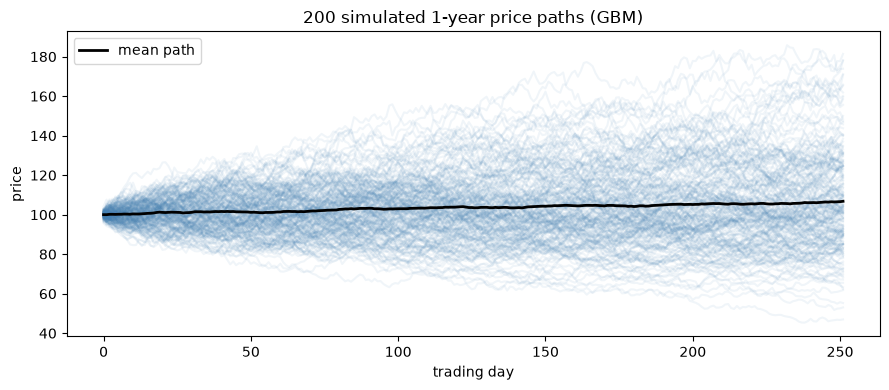

In [11]:
try:
    import matplotlib.pyplot as plt

    rng = np.random.default_rng(99)
    n_days, n_show = 252, 200
    shocks = rng.normal((0.07 - 0.5 * 0.25**2) / 252, 0.25 / np.sqrt(252),
                        size=(n_days, n_show))
    paths = 100 * np.exp(np.cumsum(shocks, axis=0))

    plt.figure(figsize=(9, 4))
    plt.plot(paths, alpha=0.08, color="steelblue")
    plt.plot(paths.mean(axis=1), color="black", lw=2, label="mean path")
    plt.title("200 simulated 1-year price paths (GBM)")
    plt.xlabel("trading day"); plt.ylabel("price"); plt.legend()
    plt.tight_layout(); plt.show()
except ImportError:
    print("matplotlib not installed - run: pip install matplotlib")

## 12. The vectorization mindset (do this on the job)

The single biggest NumPy habit: **replace loops over assets/days with one array operation.** Example — compute the Sharpe ratio of *every* asset in a universe at once, no loop:

In [12]:
rng = np.random.default_rng(11)
universe = rng.normal(0.0003, 0.011, size=(252, 50))   # 50 assets, 1 year of daily returns

# One line, all 50 Sharpes (rf = 0). axis=0 reduces over days, per asset.
sharpes = universe.mean(axis=0) / universe.std(axis=0) * np.sqrt(252)

print("computed", sharpes.shape[0], "Sharpe ratios with zero loops")
print("best asset index:", sharpes.argmax(), " Sharpe:", round(sharpes.max(), 2))
print("top-5 assets by Sharpe:", np.argsort(sharpes)[-5:][::-1])

computed 50 Sharpe ratios with zero loops
best asset index: 21  Sharpe: 2.18
top-5 assets by Sharpe: [21 34 13 22 16]


`argmax`/`argsort` return **indices**, not values — exactly what you need to rank a universe and pick the top names (you'll do precisely this in the QuantConnect momentum strategy later in the series).

## Cheat sheet

| Task | NumPy |
|---|---|
| Create | `np.array`, `np.arange`, `np.linspace`, `np.zeros`, `np.ones`, `np.full` |
| Random (seeded) | `rng = np.random.default_rng(seed)`; `rng.normal(...)`, `rng.uniform(...)` |
| Shape info | `a.shape`, `a.ndim`, `a.size`, `a.dtype`, `a.reshape(...)` |
| Slice / column | `a[1:5]`, `a[:, 2]` (col), `a[3, :]` (row); copy with `.copy()` |
| Mask / select | `a[a > 0]`, `(c1) & (c2)`, `np.where(cond, x, y)` |
| Prices→returns | `p[1:]/p[:-1] - 1` (simple); `np.diff(np.log(p))` (log) |
| Aggregate | `a.mean(axis=0)` per-column, `axis=1` per-row, none = scalar |
| Cumulative | `np.cumsum`, `np.cumprod`, `np.maximum.accumulate` (running peak) |
| Portfolio | `R @ w` (returns), `w @ cov @ w` (variance), `np.cov(R, rowvar=False)` |
| Rank | `argmax`, `argmin`, `argsort` (return **indices**) |

**Golden rule:** if you're writing a Python `for` loop over prices or assets, ask whether a vectorized array op does it instead. Usually it does.

## Try it yourself

1. **Sharpe from scratch.** Given a price array, write a one-expression annualized Sharpe (rf = 0). Then add a non-zero risk-free rate.
2. **Rolling? Not yet.** Try to compute a 20-day moving average with pure NumPy slicing. Notice it's awkward — that pain is exactly why **Pandas** (next notebook) exists.
3. **Two-asset frontier.** For two assets with given vols and a correlation you pick, sweep the weight of asset A from 0→1 (`np.linspace`) and compute portfolio vol at each weight. Where is it lowest?
4. **Bigger Monte Carlo.** Re-run the simulation with `sigma = 0.40`. How does the 95% VaR change? Why?
5. **Drawdown duration.** Using the equity/drawdown arrays from §8, find the index of the worst drawdown with `argmin`.

---

### What's next
**Notebook 02 — Pandas for Financial Data:** labeled, time-indexed data built on top of these arrays — `DataFrame`s, `DatetimeIndex`, `resample`, `rolling`, `pct_change`, `groupby`. That's the bridge straight into QuantConnect's research environment.

**NumPy docs:** [Absolute beginners guide](https://numpy.org/doc/stable/user/absolute_beginners.html) · [Broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html) · [Random generator](https://numpy.org/doc/stable/reference/random/generator.html)

*MAT Education · Foundations · Module 1.*